In [3]:
import pandas as pd
import numpy as np
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn

torch.cuda.empty_cache()
gc.collect()

df = pd.read_csv('/content/drive/MyDrive/NLP_Project/combined_with_hotels.csv')
texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)
MODEL_NAME = "qarib/bert-base-qarib"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print(f"Downloading {MODEL_NAME} Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./qarib_13k_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(f"Starting Final Showdown with {MODEL_NAME} on the 13K dataset...")
trainer.train()

config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizing data...


Map:   0%|          | 0/10782 [00:00<?, ? examples/s]

Map:   0%|          | 0/2696 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2696, training_loss=1.095189567135774, metrics={'train_runtime': 780.3381, 'train_samples_per_second': 55.268, 'train_steps_per_second': 3.455, 'total_flos': 2836888869943296.0, 'train_loss': 1.095189567135774, 'epoch': 4.0})

Predicting on Test Data with qarib/bert-base-qarib...



QARiB (13K Dataset) - Final Classification Report
              precision    recall  f1-score   support

        -1.0       0.91      0.91      0.91       914
         0.0       0.45      0.42      0.44        81
         1.0       0.95      0.95      0.95      1701

    accuracy                           0.92      2696
   macro avg       0.77      0.76      0.76      2696
weighted avg       0.92      0.92      0.92      2696



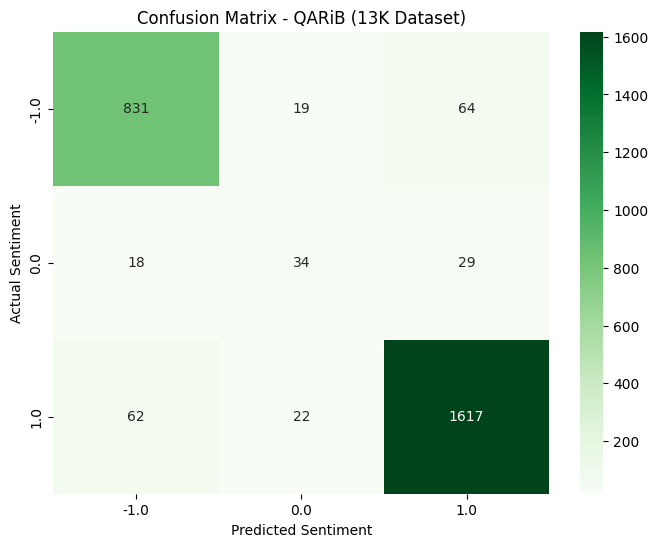

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print(f"Predicting on Test Data with {MODEL_NAME}...")
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids
target_names = [str(cls) for cls in encoder.classes_]
print("\n" + "="*50)
print(f"QARiB (13K Dataset) - Final Classification Report")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - QARiB (13K Dataset)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()